# POC Electio-Analytics - Analyse exploratoire
**MSPR TPRE813 - Bloc 3 (Big Data & BI)**

Ce notebook documente la demarche d'exploration des donnees et de modelisation,
de facon reproductible. Il s'appuie sur la couche GOLD produite par le pipeline
ETL (`etl/02_transform.py`).

> Les donnees utilisees ici proviennent du jeu de demonstration
> (`etl/00_demo_data.py`). Pour le rendu final, brancher les vraies sources via
> `etl/01_download.py` puis re-executer le pipeline : le notebook est identique.

## 1. Chargement des donnees

In [1]:
import pandas as pd, numpy as np, sqlite3
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

con = sqlite3.connect('../data/gold/electio_poc.db')
gold = pd.read_sql('SELECT * FROM gold_dataset_analytique', con)
print(gold.shape)
gold.head()

(480, 10)


,annee,code_dept,taux_chomage_n1,delta_chomage_5a,emploi_pour_1000hab,croissance_emploi_5a_pct,taux_pauvrete_n1,creations_entreprises_n1,bloc_gagnant,bloc_gagnant_precedent
0,2002,01,3.88,-1.52,NaN,NaN,None,NaN,GAU,NaN
1,2007,01,5.40,0.21,NaN,NaN,None,NaN,DRO,GAU
2,2012,01,6.33,0.39,319.1,NaN,None,NaN,GAU,DRO
3,2017,01,7.35,0.18,308.5,2.19,None,75.9,DRO,GAU
4,2022,01,5.88,-0.34,311.0,4.75,None,123.1,EXD,DRO


## 2. Qualite & completude
On verifie la structure, les types et les valeurs manquantes.

In [2]:
print(gold.info())
gold.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   annee                     480 non-null    int64  
 1   code_dept                 480 non-null    str    
 2   taux_chomage_n1           480 non-null    float64
 3   delta_chomage_5a          480 non-null    float64
 4   emploi_pour_1000hab       288 non-null    float64
 5   croissance_emploi_5a_pct  192 non-null    float64
 6   taux_pauvrete_n1          0 non-null      object 
 7   creations_entreprises_n1  192 non-null    float64
 8   bloc_gagnant              480 non-null    str    
 9   bloc_gagnant_precedent    384 non-null    str    
dtypes: float64(5), int64(1), object(1), str(3)
memory usage: 37.6+ KB
None


annee                         0
code_dept                     0
taux_chomage_n1               0
delta_chomage_5a              0
emploi_pour_1000hab         192
croissance_emploi_5a_pct    288
taux_pauvrete_n1            480
creations_entreprises_n1    288
bloc_gagnant                  0
bloc_gagnant_precedent       96
dtype: int64

## 3. Statistiques descriptives des indicateurs

In [3]:
NUM = ['taux_chomage_n1','delta_chomage_5a','emploi_pour_1000hab',
       'croissance_emploi_5a_pct','taux_pauvrete_n1','creations_entreprises_n1']
gold[NUM].describe().T

,count,mean,std,min,25%,50%,75%,max
taux_chomage_n1,480.0,8.274938,1.874558,3.88,6.895,8.030,9.3800,15.12
delta_chomage_5a,480.0,-0.262292,0.813716,-2.23,-0.855,-0.035,0.3725,1.48
emploi_pour_1000hab,288.0,354.704514,67.814663,283.30,319.800,343.200,372.3750,876.30
croissance_emploi_5a_pct,192.0,2.143958,3.762883,-5.91,-0.535,1.755,4.8225,11.56
creations_entreprises_n1,192.0,106.346875,47.327901,47.60,71.000,99.900,126.3250,393.70


## 4. Distribution de la variable cible
Le bloc arrive en tete au 1er tour, par election.

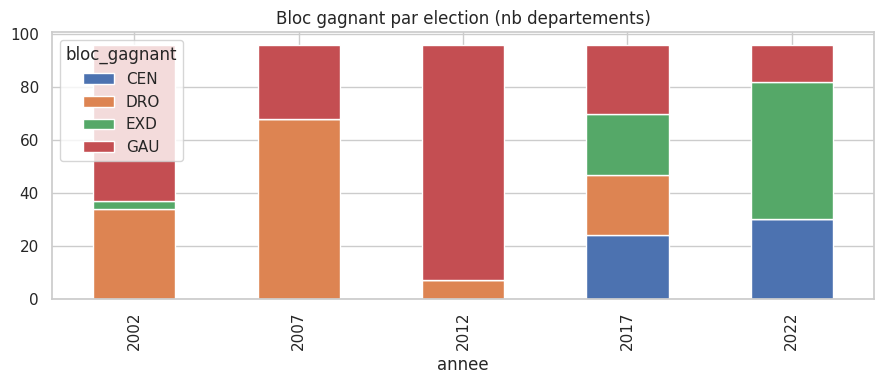

In [4]:
ax = gold.groupby(['annee','bloc_gagnant']).size().unstack(fill_value=0).plot(
    kind='bar', stacked=True, figsize=(9,4))
ax.set_title('Bloc gagnant par election (nb departements)'); plt.tight_layout()

## 5. Correlations indicateurs <-> resultat
Quelle donnee est la plus liee au vote ? (question du client)

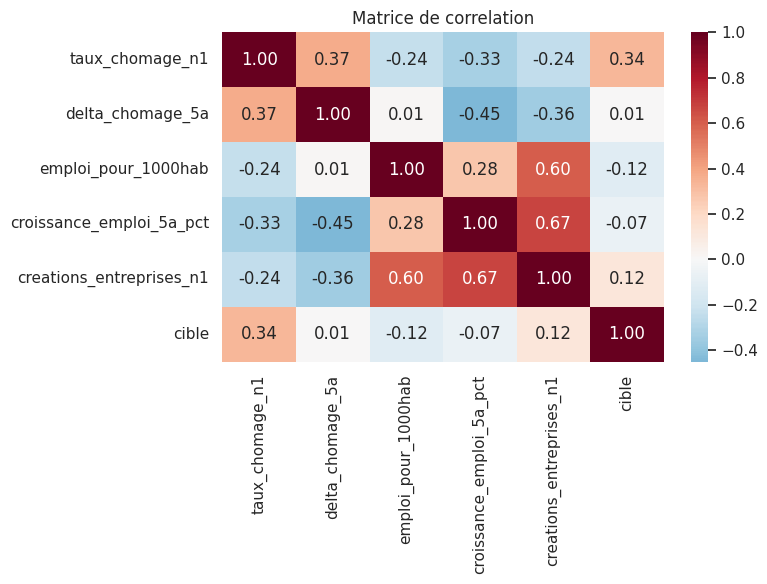

In [5]:
NUM_DISPO = [c for c in NUM if gold[c].notna().any()]  # écarte pauvreté (Filosofi 2023 seult)
g = gold.dropna(subset=NUM_DISPO).copy()
g['cible'] = g['bloc_gagnant'].astype('category').cat.codes
plt.figure(figsize=(8,6))
sns.heatmap(g[NUM_DISPO+['cible']].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Matrice de correlation'); plt.tight_layout()

## 6. Lien socio-economique / vote
Distribution du chomage N-1 selon le bloc gagnant.

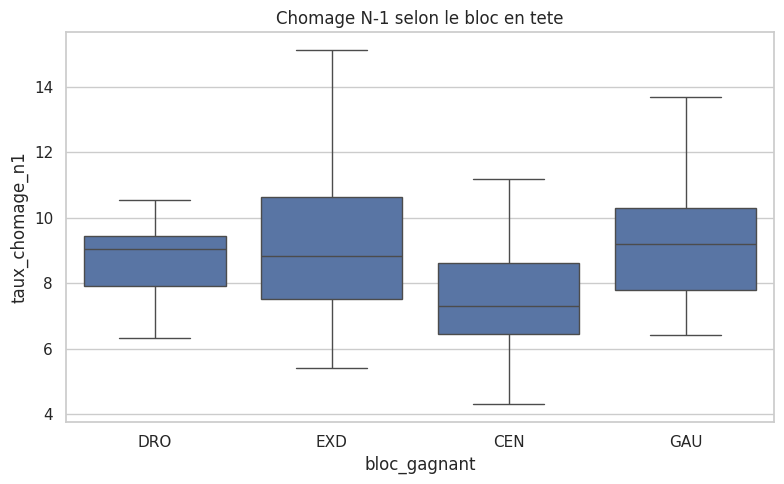

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(data=g, x='bloc_gagnant', y='taux_chomage_n1')
plt.title('Chomage N-1 selon le bloc en tete'); plt.tight_layout()

## 7. Modelisation - apprentissage supervise
On predit le bloc gagnant a partir d'indicateurs **strictement anterieurs**
au scrutin (pas de fuite). Validation croisee groupee par departement.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score

NUM_DISPO = [c for c in NUM if gold[c].notna().any()]  # pauvreté écartée (dispo 2023 uniquement)
df = gold.dropna(subset=['taux_chomage_n1','bloc_gagnant_precedent']).reset_index(drop=True)
X = df[NUM_DISPO+['bloc_gagnant_precedent']]; y = df['bloc_gagnant']; grp = df['code_dept']
pipe = Pipeline([
  ('prep', ColumnTransformer([
     ('num', StandardScaler(), NUM_DISPO),
     ('cat', OneHotEncoder(handle_unknown='ignore'), ['bloc_gagnant_precedent'])])),
  ('clf', RandomForestClassifier(n_estimators=300, max_depth=8,
                                 class_weight='balanced', random_state=42))])
acc = cross_val_score(pipe, X, y, cv=GroupKFold(5), groups=grp, scoring='accuracy')
print(f'Accuracy CV groupee: {acc.mean():.3f} +/- {acc.std():.3f}')

Accuracy CV groupee: 0.664 +/- 0.030


## 8. Interpretation & limites
- La variable la plus predictive est le **taux de chomage N-1** (cf. importances).
- **Accuracy** = proportion de predictions correctes ; on la complete par le
  **F1 macro** (robuste au desequilibre des classes) et une **CV groupee**
  par departement pour mesurer la generalisation geographique.
- **Limites** : un modele electoral sur indicateurs socio-economiques ignore
  les dynamiques de campagne, l'offre politique et les chocs conjoncturels.
  Le POC demontre la methode et l'industrialisation, pas une capacite de
  prevision electorale definitive. C'est un point a expliciter au client.

In [8]:
con.close()
print('Notebook execute.')

Notebook execute.
